In [1]:
from IPython.core.interactiveshell import InteractiveShell # 这个对象设置所有行全部输出

# 设置该对象ast_node_interactivity属性的值为all，表示在notebook下每一行有输出的代码全部输出运算结果
InteractiveShell.ast_node_interactivity = "all" 

# 导入红酒检测数据集
from sklearn.datasets import load_wine

# 加载sklearn自带红酒检测数据集
wine = load_wine()

# 获取数据集形状
wine.data.shape

# 获取标签
wine.target.shape

(178,)

In [2]:
wine_data = wine.data
wine_data.shape

(178, 13)

In [3]:
import pandas as pd

# 拼接data和target，轴1方向拼接（列方向）
wine_pd = pd.concat([pd.DataFrame(wine.data),pd.DataFrame(wine.target)],axis = 1)

# 展示数据：为标签字段添加列索引名称
wine.feature_names.append("class")

# 设置标签的列索引名称
wine_pd.columns = wine.feature_names
wine_pd.shape

(178, 14)

In [4]:
wine_pd.isnull().any()

alcohol                         False
malic_acid                      False
ash                             False
alcalinity_of_ash               False
magnesium                       False
total_phenols                   False
flavanoids                      False
nonflavanoid_phenols            False
proanthocyanins                 False
color_intensity                 False
hue                             False
od280/od315_of_diluted_wines    False
proline                         False
class                           False
dtype: bool

In [5]:
wine_pd.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
class                           0
dtype: int64

<Axes: >

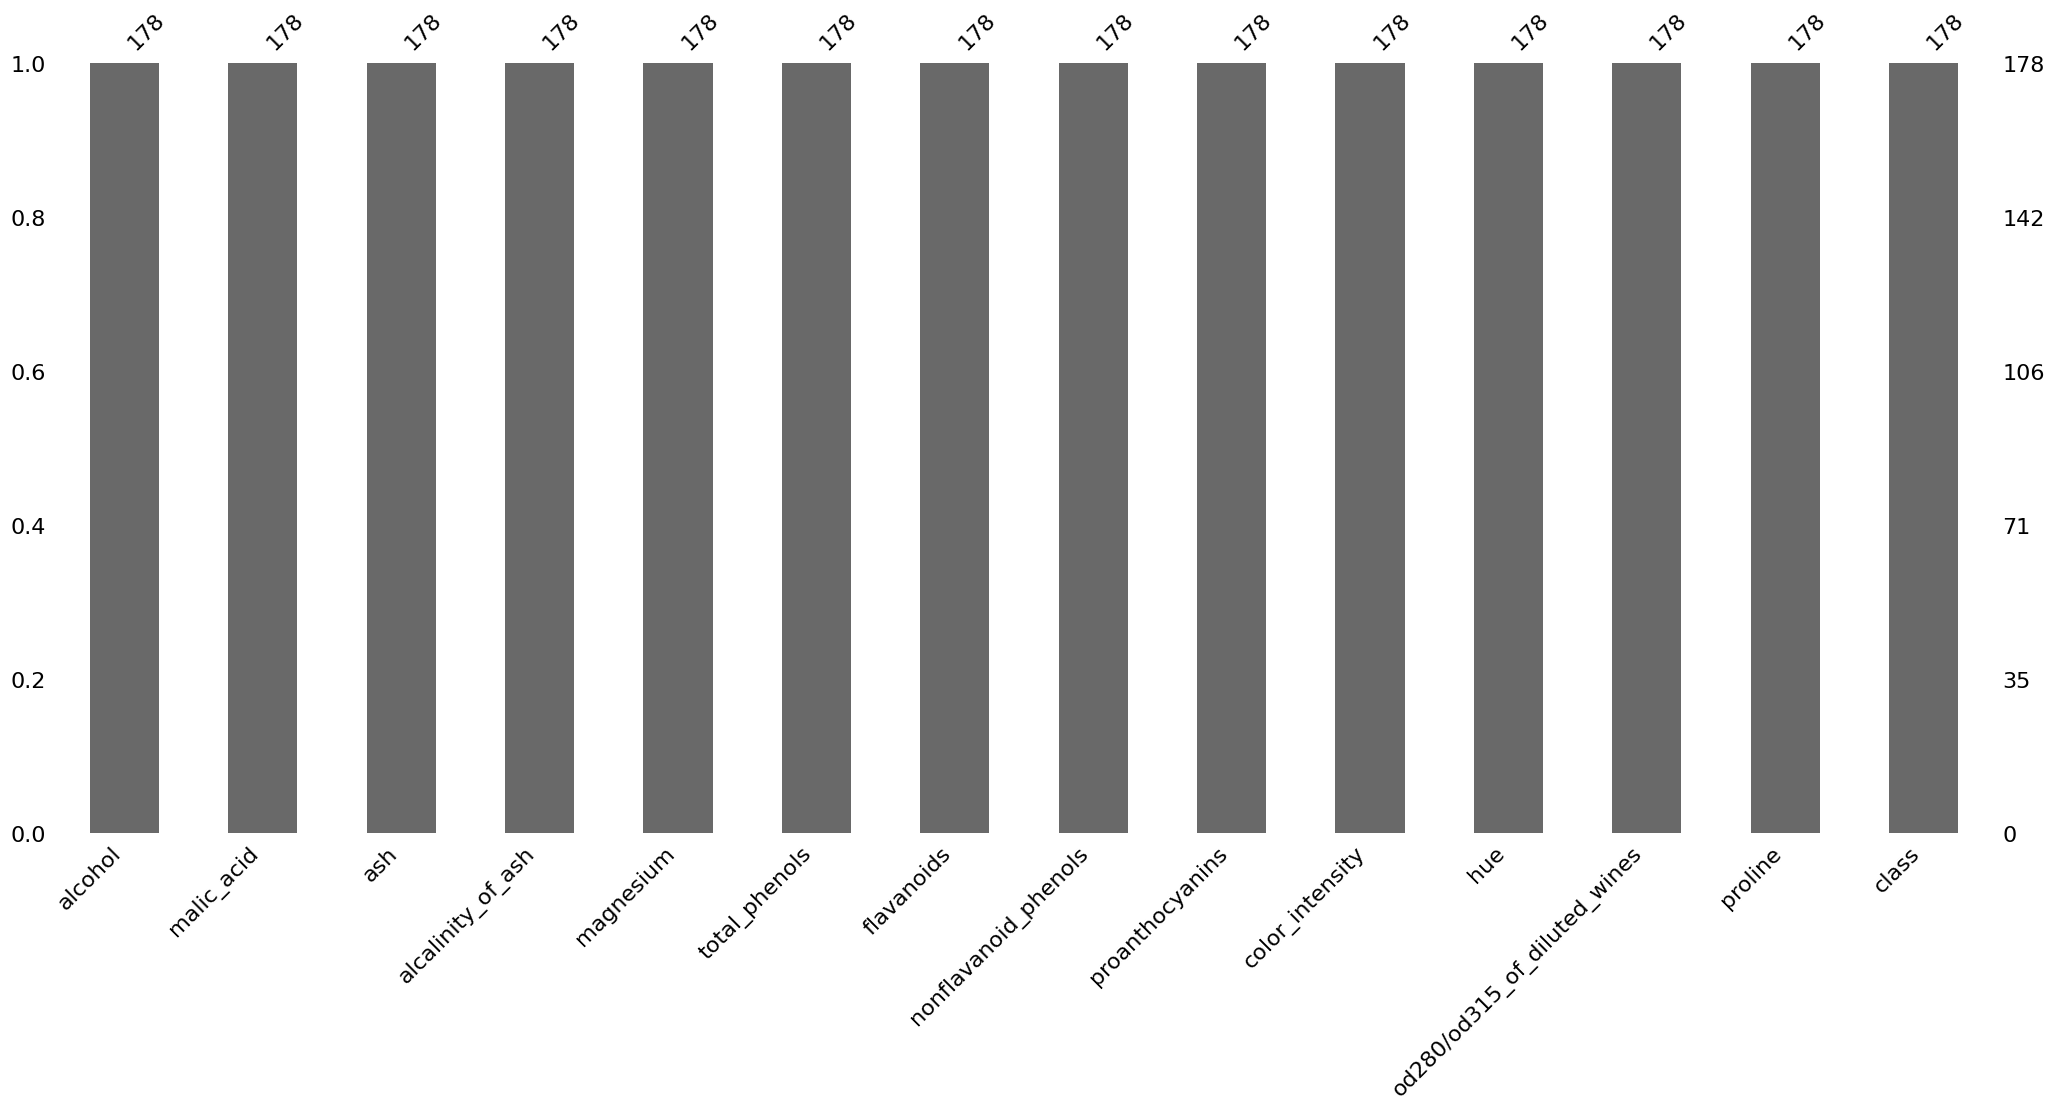

In [6]:
# 导包
import missingno as ms
ms.bar(wine_pd)

In [7]:
pd.DataFrame([(c, wine_pd[c].isnull().sum(),wine_pd[c].isnull().mean()*100) for c in wine_pd.iloc[:,:-1]], columns=["column_name", 'missing_num',"percentage"])


,column_name,missing_num,percentage
0,alcohol,0,0.0
1,malic_acid,0,0.0
2,ash,0,0.0
3,alcalinity_of_ash,0,0.0
4,magnesium,0,0.0
5,total_phenols,0,0.0
6,flavanoids,0,0.0
7,nonflavanoid_phenols,0,0.0
8,proanthocyanins,0,0.0
9,color_intensity,0,0.0


In [14]:
# 标准化处理案例
from sklearn.preprocessing import StandardScaler

data_standar = pd.DataFrame(
    # 完成标准化：实例化StandardScaler()对象，调用fit_transform()方法完成标准化处理 - 将不为type的其余所有特征全部完成标准化处理
    data=StandardScaler().fit_transform(wine_pd[[col for col in wine_pd.columns if col != 'type']]),
    columns=([[col for col in wine_pd.columns if col != 'type']])
)
data_standar
data_standar.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009,-1.213944
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242,-1.213944
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148,-1.213944
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574,-1.213944
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874,-1.213944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.876275,2.974543,0.305159,0.301803,-0.332922,-0.985614,-1.424900,1.274310,-0.930179,1.142811,-1.392758,-1.231206,-0.021952,1.373864
174,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893,1.373864
175,0.332758,1.744744,-0.389355,0.151661,1.422412,-1.129824,-1.344582,0.549108,-0.422075,2.224236,-1.612125,-1.485445,0.280575,1.373864
176,0.209232,0.227694,0.012732,0.151661,1.422412,-1.033684,-1.354622,1.354888,-0.229346,1.834923,-1.568252,-1.400699,0.296498,1.373864


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,178.000000,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02
mean,-8.382808e-16,-1.197544e-16,-8.370333e-16,-3.991813e-17,-3.991813e-17,0.000000,-3.991813e-16,3.592632e-16,-1.197544e-16,2.494883e-17,1.995907e-16,3.193450e-16,-1.596725e-16,1.596725e-16
std,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00
min,-2.434235e+00,-1.432983e+00,-3.679162e+00,-2.671018e+00,-2.088255e+00,-2.107246,-1.695971e+00,-1.868234e+00,-2.069034e+00,-1.634288e+00,-2.094732e+00,-1.895054e+00,-1.493188e+00,-1.213944e+00
25%,-7.882448e-01,-6.587486e-01,-5.721225e-01,-6.891372e-01,-8.244151e-01,-0.885468,-8.275393e-01,-7.401412e-01,-5.972835e-01,-7.951025e-01,-7.675624e-01,-9.522483e-01,-7.846378e-01,-1.213944e+00
50%,6.099988e-02,-4.231120e-01,-2.382132e-02,1.518295e-03,-1.222817e-01,0.095960,1.061497e-01,-1.760948e-01,-6.289785e-02,-1.592246e-01,3.312687e-02,2.377348e-01,-2.337204e-01,7.996036e-02
75%,8.361286e-01,6.697929e-01,6.981085e-01,6.020883e-01,5.096384e-01,0.808997,8.490851e-01,6.095413e-01,6.291754e-01,4.939560e-01,7.131644e-01,7.885875e-01,7.582494e-01,1.373864e+00
max,2.259772e+00,3.109192e+00,3.156325e+00,3.154511e+00,4.371372e+00,2.539515,3.062832e+00,2.402403e+00,3.485073e+00,3.435432e+00,3.301694e+00,1.960915e+00,2.971473e+00,1.373864e+00


In [15]:
# 归一化处理案例
from sklearn.preprocessing import MinMaxScaler

#类型转换
data_minmax = pd.DataFrame(
    data=MinMaxScaler().fit_transform(wine_pd[[col for col in wine_pd.columns if col not in ['type']]]), # 直接传入归一化对象，训练并完成转换，筛选非type特征的其余所有特征
    columns=[col for col in wine_pd.columns if col not in ['type']] # 构造归一化处理完毕后的dataframe，指定列索引名称
)

data_minmax
data_minmax.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,0.842105,0.191700,0.572193,0.257732,0.619565,0.627586,0.573840,0.283019,0.593060,0.372014,0.455285,0.970696,0.561341,0.0
1,0.571053,0.205534,0.417112,0.030928,0.326087,0.575862,0.510549,0.245283,0.274448,0.264505,0.463415,0.780220,0.550642,0.0
2,0.560526,0.320158,0.700535,0.412371,0.336957,0.627586,0.611814,0.320755,0.757098,0.375427,0.447154,0.695971,0.646933,0.0
3,0.878947,0.239130,0.609626,0.319588,0.467391,0.989655,0.664557,0.207547,0.558360,0.556314,0.308943,0.798535,0.857347,0.0
4,0.581579,0.365613,0.807487,0.536082,0.521739,0.627586,0.495781,0.490566,0.444795,0.259386,0.455285,0.608059,0.325963,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.705263,0.970356,0.582888,0.510309,0.271739,0.241379,0.056962,0.735849,0.205047,0.547782,0.130081,0.172161,0.329529,1.0
174,0.623684,0.626482,0.598930,0.639175,0.347826,0.282759,0.086498,0.566038,0.315457,0.513652,0.178862,0.106227,0.336662,1.0
175,0.589474,0.699605,0.481283,0.484536,0.543478,0.210345,0.073840,0.566038,0.296530,0.761092,0.089431,0.106227,0.397290,1.0
176,0.563158,0.365613,0.540107,0.484536,0.543478,0.231034,0.071730,0.754717,0.331230,0.684300,0.097561,0.128205,0.400856,1.0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,0.518584,0.315484,0.538244,0.458502,0.323278,0.453487,0.356386,0.437460,0.372523,0.322363,0.388170,0.491460,0.334446,0.469101
std,0.213639,0.220780,0.146708,0.172142,0.155244,0.215811,0.210730,0.234818,0.180555,0.197806,0.185831,0.260070,0.224613,0.387517
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.350658,0.170455,0.454545,0.340206,0.195652,0.262931,0.182489,0.264151,0.264984,0.165529,0.245935,0.244505,0.158702,0.000000
50%,0.531579,0.222332,0.534759,0.458763,0.304348,0.474138,0.378692,0.396226,0.361199,0.290956,0.394309,0.553114,0.282097,0.500000
75%,0.696711,0.462945,0.640374,0.561856,0.402174,0.627586,0.534810,0.580189,0.485804,0.419795,0.520325,0.695971,0.504280,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [16]:
# 准备工作：准备数据集等待后续测试
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 导入缺失值填充
from sklearn.impute import SimpleImputer

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# 解决坐标轴刻度负号乱码
plt.rcParams['axes.unicode_minus'] = False

# 解决中文乱码问题
plt.rcParams['font.sans-serif'] = ['Simhei']
plt.style.use('ggplot')

#生成数据
df = pd.DataFrame({
    'student_id': [1,2,3,4,5,6,7],
    'country': ['China', 'USA', 'UK', 'Japan', 'Korea', 'China', 'USA'],
    'education': ['Master', 'Bachelor', 'Bachelor', 'Master', 'PHD', 'PHD', 'Bachelor'],
    'target': [1, 0, 1, 0, 1, 0, 1]
})
df

,student_id,country,education,target
0,1,China,Master,1
1,2,USA,Bachelor,0
2,3,UK,Bachelor,1
3,4,Japan,Master,0
4,5,Korea,PHD,1
5,6,China,PHD,0
6,7,USA,Bachelor,1


In [17]:
# get_dummies直接进行独热编码
pd.get_dummies(df, columns=['education'])

,student_id,country,target,education_Bachelor,education_Master,education_PHD
0,1,China,1,False,True,False
1,2,USA,0,True,False,False
2,3,UK,1,True,False,False
3,4,Japan,0,False,True,False
4,5,Korea,1,False,False,True
5,6,China,0,False,False,True
6,7,USA,1,True,False,False


In [18]:
# 使用sklearn的OneHotEncoder进行独热编码
from sklearn.preprocessing import OneHotEncoder

# 独热编码结果展示
pd.concat([df,pd.DataFrame(
    data=OneHotEncoder().fit_transform(
        df[['education']]).toarray(),
    columns=['education_Bachelor','education_Master','education_PHD']
)],axis=1)

,student_id,country,education,target,education_Bachelor,education_Master,education_PHD
0,1,China,Master,1,0.0,1.0,0.0
1,2,USA,Bachelor,0,1.0,0.0,0.0
2,3,UK,Bachelor,1,1.0,0.0,0.0
3,4,Japan,Master,0,0.0,1.0,0.0
4,5,Korea,PHD,1,0.0,0.0,1.0
5,6,China,PHD,0,0.0,0.0,1.0
6,7,USA,Bachelor,1,1.0,0.0,0.0


In [19]:
# 使用LabelEncoder进行标签编码
from sklearn.preprocessing import LabelEncoder

df['country_LabelEncoder'] = LabelEncoder().fit_transform(df['country'])
df

,student_id,country,education,target,country_LabelEncoder
0,1,China,Master,1,0
1,2,USA,Bachelor,0,4
2,3,UK,Bachelor,1,3
3,4,Japan,Master,0,1
4,5,Korea,PHD,1,2
5,6,China,PHD,0,0
6,7,USA,Bachelor,1,4


In [21]:
# 序列编码
df['education'] = df['education'].map(
                    {'Bachelor': 1, 
                    'Master': 2, 
                    'PHD': 3})
df.head()

from sklearn.preprocessing import OrdinalEncoder
OrdinalEncoder().fit_transform(wine_pd)

,student_id,country,education,target,country_LabelEncoder
0,1,China,NaN,1,0
1,2,USA,NaN,0,4
2,3,UK,NaN,1,3
3,4,Japan,NaN,0,1
4,5,Korea,NaN,1,2


array([[118.,  43.,  44., ..., 120.,  94.,   0.],
       [ 65.,  49.,  18., ..., 102.,  92.,   0.],
       [ 63.,  71.,  63., ...,  86., 101.,   0.],
       ...,
       [ 68., 119.,  29., ...,  10.,  74.,   2.],
       [ 64.,  81.,  38., ...,  14.,  75.,   2.],
       [112., 117.,  69., ...,  13.,  40.,   2.]], shape=(178, 14))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2.0


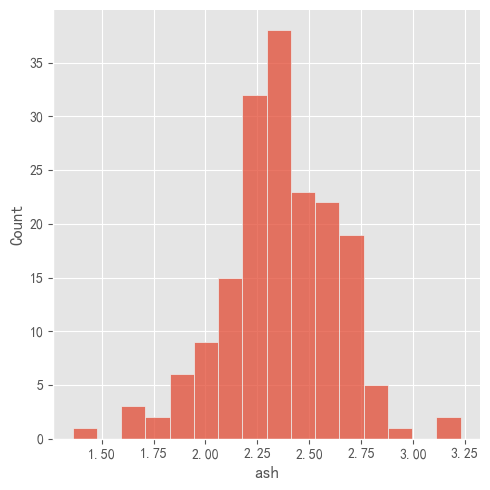

In [23]:
# 准备工作：准备数据集等待后续测试
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 导入缺失值填充
from sklearn.impute import SimpleImputer

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# 解决坐标轴刻度负号乱码
plt.rcParams['axes.unicode_minus'] = False

# 解决中文乱码问题
plt.rcParams['font.sans-serif'] = ['Simhei']
plt.style.use('ggplot')

data = pd.DataFrame(wine_pd)

data = pd.DataFrame(
    data=SimpleImputer(
        missing_values=np.nan,
        strategy='most_frequent'
    ).fit_transform(data),
    columns=data.columns
)
data

# 切片出ash特征，绘制单变量观测分布图
sns.displot(data['ash'], kde=False)

array([1.35813, 1.8275 , 2.295  , 2.7625 , 3.23   ])

,ash
0,"(2.295, 2.762]"
1,"(1.828, 2.295]"
2,"(2.295, 2.762]"
3,"(2.295, 2.762]"
4,"(2.762, 3.23]"
...,...
173,"(2.295, 2.762]"
174,"(2.295, 2.762]"
175,"(1.828, 2.295]"
176,"(2.295, 2.762]"


<Axes: xlabel='bins', ylabel='count'>

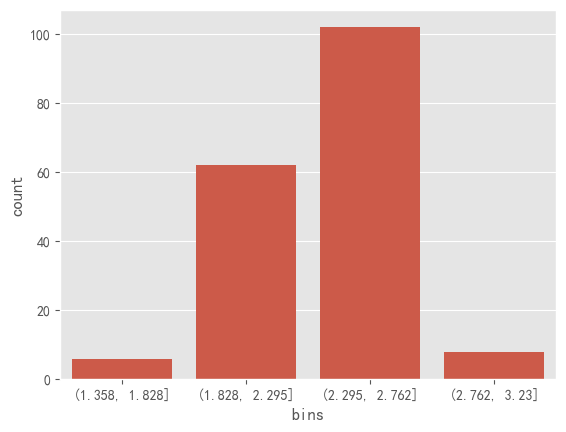

In [24]:
# 等宽分箱法
# cut方法的几个必备参数：
# bins：给定划分点n，得到n+1个分组；
# retbins：布尔类型值，为True表示返回bin的具体范围值
# precision:显示bins的精度，默认为3

# 进行等宽分箱，返回值cutoff：表示得到的四个分组的所有划分点（划分点数=分组数+1）；value：返回的分箱后的结果数据
value, cutoff = pd.cut(data['ash'], bins=4, retbins=True)

cutoff
df = value.to_frame() # 转换为dataframe
df
df.columns = ['bins'] # 设置列索引名称
sns.countplot(x='bins', data=df) # countplot绘制的是分箱器观测分布图；

array([1.        , 2.66666667, 4.33333333, 6.        ])

,test
0,"(0.999, 2.667]"
1,"(0.999, 2.667]"
2,"(2.667, 4.333]"
3,"(2.667, 4.333]"
4,"(4.333, 6.0]"
5,"(4.333, 6.0]"


<Axes: xlabel='test', ylabel='count'>

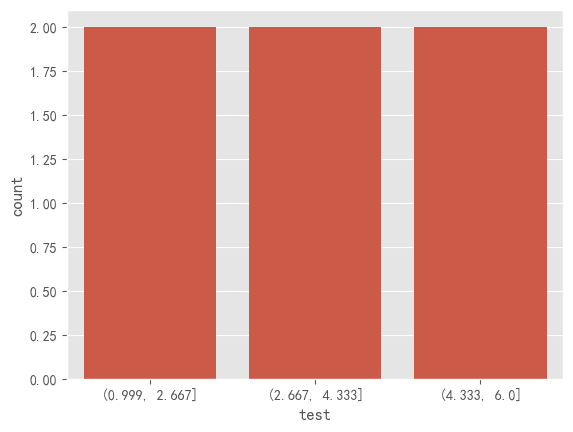

In [25]:
# 准备一个测试数据：
s1 = pd.Series([1,2,3,4,5,6])

# 等频分箱法实现
value, cutoff = pd.qcut(x=s1, q=3, retbins=True) # 参数：分箱的数据、几个箱
cutoff # 查看分箱的划分点
df = value.to_frame() # 转换为dataframe
df.columns = ['test'] # 设置列索引名称
df
sns.countplot(x='test',data=df) # 绘制分箱器观测分布图

,tests
0,"(0.999, 3.667]"
1,"(0.999, 3.667]"
2,"(0.999, 3.667]"
3,"(3.667, 6.0]"
4,"(3.667, 6.0]"
5,"(3.667, 6.0]"
6,"(3.667, 6.0]"
7,"(3.667, 6.0]"
8,"(3.667, 6.0]"


<Axes: xlabel='tests', ylabel='count'>

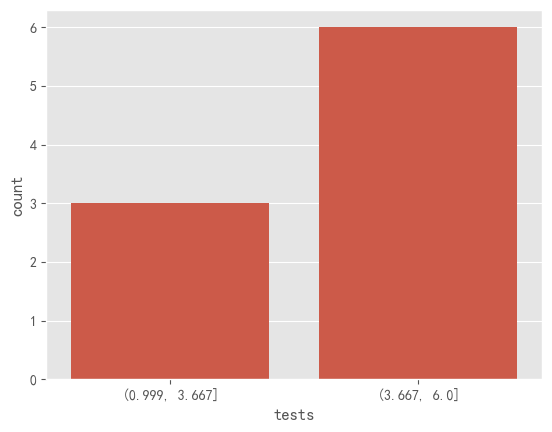

In [26]:
# 特殊情况演示：
s1 = pd.Series([1,2,3,4,5,6,6,6,6])

# 获取分箱结果和划分点
value, cutoff = pd.qcut(x=s1, q=3, duplicates='drop', retbins=True) # 输入数据是x，q表示分3箱
df = value.to_frame()
df.columns = ['tests']
df
sns.countplot(x='tests',data=df)

,ash
0,"(2.36, 2.558]"
1,"(1.3590000000000002, 2.21]"
2,"(2.558, 3.23]"
3,"(2.36, 2.558]"
4,"(2.558, 3.23]"
...,...
173,"(2.36, 2.558]"
174,"(2.36, 2.558]"
175,"(2.21, 2.36]"
176,"(2.36, 2.558]"


<Axes: xlabel='ash', ylabel='count'>

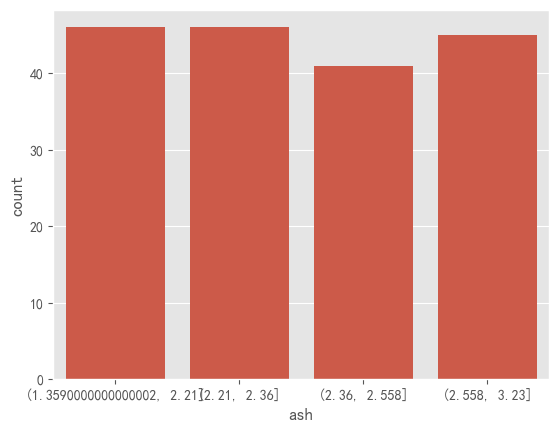

In [27]:
# 等频分箱
value,cufoff = pd.qcut(x=data['ash'],q=4,duplicates='drop',retbins=True)
df = value.to_frame()
df.columns = ['ash']
df
sns.countplot(x='ash',data=df)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,result
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


,mean radius
0,a7
1,a7
2,a7
3,a2
4,a7
...,...
564,a7
565,a7
566,a5
567,a7


<Axes: xlabel='mean radius', ylabel='count'>

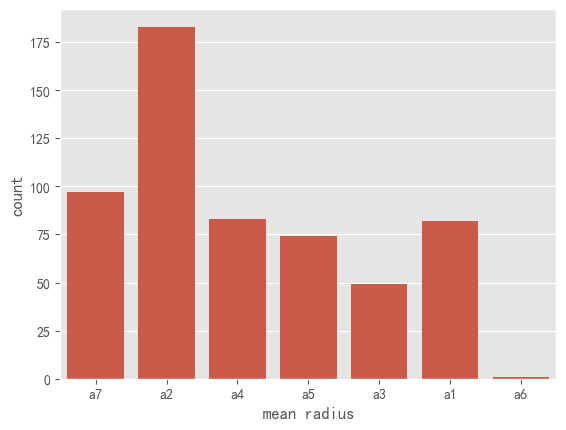

In [28]:
# 导包
from sklearn.tree import DecisionTreeClassifier

from sklearn.datasets import load_breast_cancer

data = load_breast_cancer() # 加载数据集

# 先拼接数据集和标签
df = pd.concat([pd.DataFrame(data.data),pd.DataFrame(data.target)], axis=1)

# 准备列索引，添加到数据集
df.columns = np.append(data.feature_names,'result')
df

# 构建决策树模型
clf = DecisionTreeClassifier(criterion='entropy', max_depth=3).fit(df['mean radius'].values.reshape(-1,1),df['result'])
# 选择信息增益进行最有特征划分，即表示这里选择的是ID3算法，同时预剪枝，规定树的最大深度为3

# 获取当前树的所有叶子节点的分割点的阈值
cut_points = clf.tree_.threshold[np.where(clf.tree_.children_left > -1)]

# 展示分割点
cutoff = [np.round(x,3) for x in np.sort(cut_points).tolist()]

# 注意这里只给出了6个点，但是相当于分了7个箱子，假设箱子编号为a1-a7，接下来完成分箱可视化
l = df['mean radius'].values.tolist() # 特征列的值全部取出，转换为普通列表
res = [] # 准备分箱结果序列

for i in l: # 循环遍历特征的所有值
    
    if i < cutoff[0]: # 如果遍历到的值小于第一个切分点
        res.append('a1') # 分到a1箱
    elif i >= cutoff[-1]: # 如果遍历到的值大于最后一个切分点
        res.append('a7') # 分到a7箱
    else:
        for j in range(0,5): # 否则直接构造a2-a6箱
            if i > cutoff[j] and i <= cutoff[j+1]: # 如果遍历的值大于当前切分点，小于下一个切分点
                res.append('a{}'.format(j+2)) # 生成一个新的箱，然后立刻结束本循环
                break
res = pd.DataFrame(data=res,columns=['mean radius']) # 构造为dataframe
res
sns.countplot(x='mean radius',data=res) # 绘制分箱器观测分布图

In [29]:
# 导入红酒数据集
from sklearn.datasets import load_wine

# 导入方差过滤器对象VarianceThreshold
from sklearn.feature_selection import VarianceThreshold

# 未进行方差过滤的数据集
wine = load_wine().data
# 交由VarianceThreshold进行方差过滤，设置方差阈值为0.1后获得的数据集
VarianceThreshold(threshold = 0.1).fit_transform(load_wine().data)

array([[  14.23,    1.71,   15.6 , ...,    5.64,    3.92, 1065.  ],
       [  13.2 ,    1.78,   11.2 , ...,    4.38,    3.4 , 1050.  ],
       [  13.16,    2.36,   18.6 , ...,    5.68,    3.17, 1185.  ],
       ...,
       [  13.27,    4.28,   20.  , ...,   10.2 ,    1.56,  835.  ],
       [  13.17,    2.59,   20.  , ...,    9.3 ,    1.62,  840.  ],
       [  14.13,    4.1 ,   24.5 , ...,    9.2 ,    1.6 ,  560.  ]],
      shape=(178, 10))

In [30]:
from sklearn.datasets import load_iris
iris = load_iris()

# 特征选择
from sklearn.feature_selection import SelectKBest # 选择最佳特征列，依据卡方检验分数移除top k之外的特征
from sklearn.feature_selection import chi2        # 卡方检验

models = SelectKBest(chi2,k=2)
new_data = models.fit_transform(iris.data,iris.target)
models.scores_
models.pvalues_

array([ 10.81782088,   3.7107283 , 116.31261309,  67.0483602 ])

array([4.47651499e-03, 1.56395980e-01, 5.53397228e-26, 2.75824965e-15])

In [31]:
# 导入数据
from sklearn.datasets import load_iris

# 加载数据集
irisdata = load_iris()

# 特征选择（pearson相关系数法）
# 选择最佳特征列，依据皮尔逊相关系数值及其置信度分数移除top k之外的特征
from sklearn.feature_selection import SelectKBest  

# 计算皮尔森相关系数，同时还会计算置信度
from scipy.stats import pearsonr
from numpy import array

models = SelectKBest( # 这里需要传入皮尔逊相关系数计算结果及其置信度
    lambda X, Y: tuple( # 这里要返回一个二元组（相关系数值，置信度），
        # 以一个二维二元组结构对象返回，其第i项表示第i个特征的相关系数值和置信度
        map( # 二维二元组使用map函数构造，指定第二维元组构造方法为tuple内置类
            # array数组作为第二维元组构建返回结果的容器
            tuple,array( # 对list类型结果构造为array数组
                list( # 将map迭代器对象结果构造为list
                    map(
                        lambda x:pearsonr(x, Y), X.T # map第一个参数接收一个函数
                        # 函数为匿名函数，接收的参数为特征矩阵X的转置和标签y
                        # map的第二个参数为此处lambda匿名函数所需的第一个参数
                    )
                )
            ).T
        )
    ), k=3) # 传入k值，表示取皮尔逊相关系数值最高的k个列)

# 获得过滤特征后的数据集
models.fit_transform(irisdata.data, irisdata.target)
# 查看相关系数值
models.scores_
# 查看置信度
models.pvalues_

array([[5.1, 1.4, 0.2],
       [4.9, 1.4, 0.2],
       [4.7, 1.3, 0.2],
       [4.6, 1.5, 0.2],
       [5. , 1.4, 0.2],
       [5.4, 1.7, 0.4],
       [4.6, 1.4, 0.3],
       [5. , 1.5, 0.2],
       [4.4, 1.4, 0.2],
       [4.9, 1.5, 0.1],
       [5.4, 1.5, 0.2],
       [4.8, 1.6, 0.2],
       [4.8, 1.4, 0.1],
       [4.3, 1.1, 0.1],
       [5.8, 1.2, 0.2],
       [5.7, 1.5, 0.4],
       [5.4, 1.3, 0.4],
       [5.1, 1.4, 0.3],
       [5.7, 1.7, 0.3],
       [5.1, 1.5, 0.3],
       [5.4, 1.7, 0.2],
       [5.1, 1.5, 0.4],
       [4.6, 1. , 0.2],
       [5.1, 1.7, 0.5],
       [4.8, 1.9, 0.2],
       [5. , 1.6, 0.2],
       [5. , 1.6, 0.4],
       [5.2, 1.5, 0.2],
       [5.2, 1.4, 0.2],
       [4.7, 1.6, 0.2],
       [4.8, 1.6, 0.2],
       [5.4, 1.5, 0.4],
       [5.2, 1.5, 0.1],
       [5.5, 1.4, 0.2],
       [4.9, 1.5, 0.2],
       [5. , 1.2, 0.2],
       [5.5, 1.3, 0.2],
       [4.9, 1.4, 0.1],
       [4.4, 1.3, 0.2],
       [5.1, 1.5, 0.2],
       [5. , 1.3, 0.3],
       [4.5, 1.3

array([ 0.78256123, -0.42665756,  0.9490347 ,  0.95654733])

array([2.89047835e-32, 5.20156326e-08, 4.20187315e-76, 4.15531102e-81])

In [32]:
# 导入绘图工具
import matplotlib.pyplot as plt

# 导入鸢尾花数据集
from sklearn.datasets import load_iris

# 导入PCA降维算法对象
from sklearn.decomposition import PCA 

import pandas as pd
import numpy as np

In [33]:
# 加载数据集
iris = load_iris()

# 获取特征和标签
X = iris.data
y = iris.target

# 查看数据集形状
X.shape

# dataframe观察数据
pd.DataFrame(X)

(150, 4)

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [34]:
# 开始降维，构建降维算法模型 - 注意：此时超参数n_components还未确定最佳取值，先随意决定降的维数
pca = PCA(n_components = 2)

# 调用估计器训练降维算法模型
pca = pca.fit(X)

# 获得降维后的新数据集
x_dr = pca.transform(X)

# 查看降维之后的数据 - 已封装fit_transform方法，可以直接一步完成降维以及降维数据集构建
#x_dr = pca.fit_transform(X)
pd.DataFrame(x_dr)

,0,1
0,-2.684126,0.319397
1,-2.714142,-0.177001
2,-2.888991,-0.144949
3,-2.745343,-0.318299
4,-2.728717,0.326755
...,...,...
145,1.944110,0.187532
146,1.527167,-0.375317
147,1.764346,0.078859
148,1.900942,0.116628


In [35]:
x_dr[y == 0,0] #第0分类中降维之后的x值
x_dr[y == 0,1] #第0分类中降维之后的y值

array([-2.68412563, -2.71414169, -2.88899057, -2.74534286, -2.72871654,
       -2.28085963, -2.82053775, -2.62614497, -2.88638273, -2.6727558 ,
       -2.50694709, -2.61275523, -2.78610927, -3.22380374, -2.64475039,
       -2.38603903, -2.62352788, -2.64829671, -2.19982032, -2.5879864 ,
       -2.31025622, -2.54370523, -3.21593942, -2.30273318, -2.35575405,
       -2.50666891, -2.46882007, -2.56231991, -2.63953472, -2.63198939,
       -2.58739848, -2.4099325 , -2.64886233, -2.59873675, -2.63692688,
       -2.86624165, -2.62523805, -2.80068412, -2.98050204, -2.59000631,
       -2.77010243, -2.84936871, -2.99740655, -2.40561449, -2.20948924,
       -2.71445143, -2.53814826, -2.83946217, -2.54308575, -2.70335978])

array([ 0.31939725, -0.17700123, -0.14494943, -0.31829898,  0.32675451,
        0.74133045, -0.08946138,  0.16338496, -0.57831175, -0.11377425,
        0.6450689 ,  0.01472994, -0.235112  , -0.51139459,  1.17876464,
        1.33806233,  0.81067951,  0.31184914,  0.87283904,  0.51356031,
        0.39134594,  0.43299606,  0.13346807,  0.09870885, -0.03728186,
       -0.14601688,  0.13095149,  0.36771886,  0.31203998, -0.19696122,
       -0.20431849,  0.41092426,  0.81336382,  1.09314576, -0.12132235,
        0.06936447,  0.59937002,  0.26864374, -0.48795834,  0.22904384,
        0.26352753, -0.94096057, -0.34192606,  0.18887143,  0.43666314,
       -0.2502082 ,  0.50377114, -0.22794557,  0.57941002,  0.10770608])

<Figure size 640x480 with 0 Axes>

Text(0.5, 1.0, 'PCA of IRIS dataset')

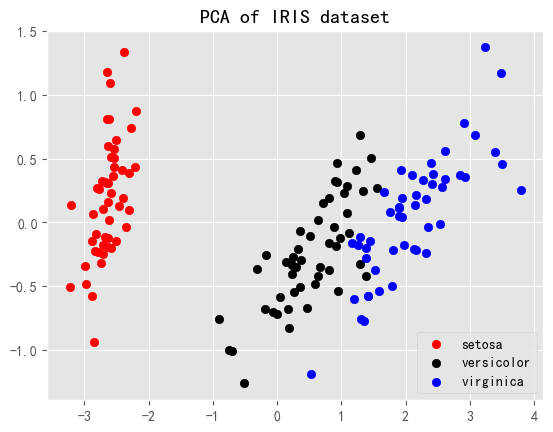

In [36]:
# 创建画布
plt.figure()

# 绘制鸢尾花三种分类下的散点图
plt.scatter(x_dr[y == 0,0], x_dr[y == 0,1], c = 'red', label=iris.target_names[0])
plt.scatter(x_dr[y == 1,0], x_dr[y == 1,1], c = 'black', label = iris.target_names[1])
plt.scatter(x_dr[y == 2,0], x_dr[y == 2,1], c = 'blue', label = iris.target_names[2])

plt.legend()
plt.title('PCA of IRIS dataset')
plt.show()

Text(0.5, 1.0, 'PCA of IRIS dataset')

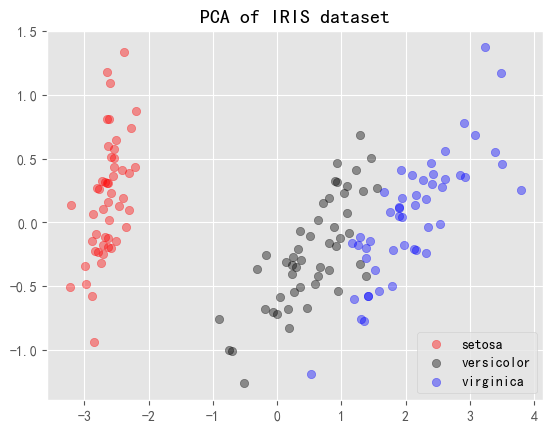

In [37]:
color = ['red','black','blue']

for i in [0,1,2]:
    plt.scatter(x_dr[y == i,0]
                ,x_dr[y == i,1]
                ,c = color[i]
                ,alpha = 0.4
                ,label = iris.target_names[i]
               )
    
plt.legend()
plt.title('PCA of IRIS dataset')
plt.show()

'\n例如：\nnp.cumsum([1,2,3,4])\n\n# ====output====\narray([1,3,6,10].dtype=int32)\n'

([<matplotlib.axis.XTick at 0x18259088250>,
 [Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3'), Text(4, 0, '4')])

Text(0.5, 0, 'number of components after dimension reduction')

Text(0, 0.5, 'cumulative explained variance ratio')

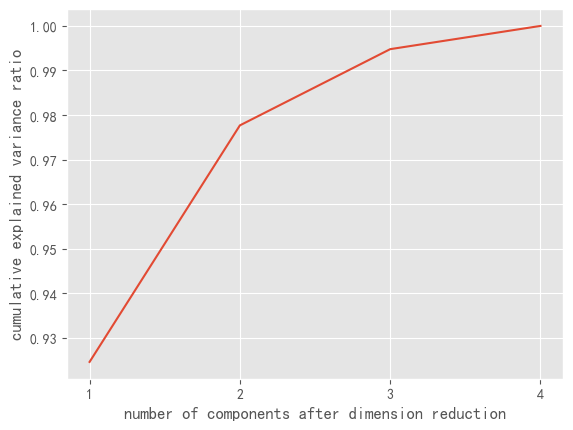

In [38]:
# 构建PCA降维算法模型
pca_line = PCA().fit(X)

#对使用不同个数的特征所带信息量的值进行累加

# 注意：np.cumsum()是用来做累加的
'''
例如：
np.cumsum([1,2,3,4])

# ====output====
array([1,3,6,10].dtype=int32)
'''

# 横坐标为不同所降的维数，纵坐标为降维后新特征矩阵捕捉到的可解释方差贡献率
plt.plot([1,2,3,4],np.cumsum(pca_line.explained_variance_ratio_))
plt.xticks([1,2,3,4])
plt.xlabel("number of components after dimension reduction")
plt.ylabel("cumulative explained variance ratio")
plt.show()

In [39]:
# n_components取值mle表示直接采用极大似然估计法自动求解最优取值
pca_mle = PCA(n_components = 'mle')
pca_mle.fit(X)
x_mle = pca_mle.transform(X)
x_mle

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",'mle'
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized 

array([[-2.68412563,  0.31939725, -0.02791483],
       [-2.71414169, -0.17700123, -0.21046427],
       [-2.88899057, -0.14494943,  0.01790026],
       [-2.74534286, -0.31829898,  0.03155937],
       [-2.72871654,  0.32675451,  0.09007924],
       [-2.28085963,  0.74133045,  0.16867766],
       [-2.82053775, -0.08946138,  0.25789216],
       [-2.62614497,  0.16338496, -0.02187932],
       [-2.88638273, -0.57831175,  0.02075957],
       [-2.6727558 , -0.11377425, -0.19763272],
       [-2.50694709,  0.6450689 , -0.07531801],
       [-2.61275523,  0.01472994,  0.10215026],
       [-2.78610927, -0.235112  , -0.20684443],
       [-3.22380374, -0.51139459,  0.06129967],
       [-2.64475039,  1.17876464, -0.15162752],
       [-2.38603903,  1.33806233,  0.2777769 ],
       [-2.62352788,  0.81067951,  0.13818323],
       [-2.64829671,  0.31184914,  0.02666832],
       [-2.19982032,  0.87283904, -0.12030552],
       [-2.5879864 ,  0.51356031,  0.21366517],
       [-2.31025622,  0.39134594, -0.239

In [40]:
#所带总的信息量的占比
pca_mle.explained_variance_ratio_.sum()

np.float64(0.9947878161267256)

In [41]:
# n_components指定0.97，表示保留97%的信息量，svd_solver取值为full表示调用LAPACK分解器来生成精确完整的SVD
pca_f = PCA(n_components = 0.97,svd_solver = 'full')
x_f = pca_f.fit_transform(X)

pca_f.explained_variance_ratio_.sum()

np.float64(0.977685206318795)

In [42]:
PCA(2).fit(X).components_

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102]])

In [45]:
 # 导入手写数字数据集
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

In [46]:
# 导入数据、探索数据
digits = load_digits()
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7'

In [47]:
digits.data.shape
digits.images.shape

(1797, 64)

(1797, 8, 8)

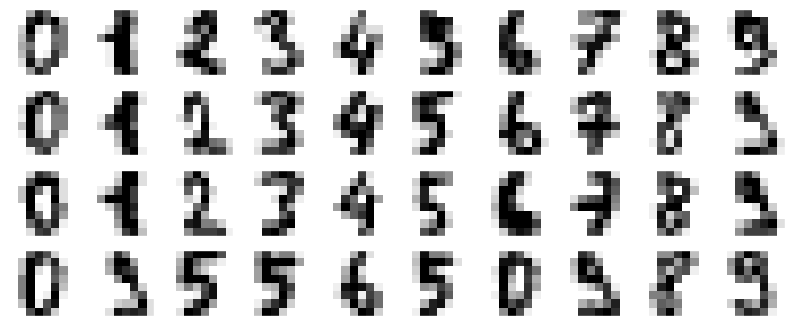

In [48]:
#传入的data必须是二维数组，并且特征要有64个
def plot_digits(data):
    fig, axes = plt.subplots(4,10
                            ,figsize=[10,4]
                            ,subplot_kw={'xticks':[],'yticks':[]})
    for i, ax in enumerate(axes.ravel()):
        ax.imshow(data[i].reshape(8,8),cmap='binary')
plot_digits(digits.data)

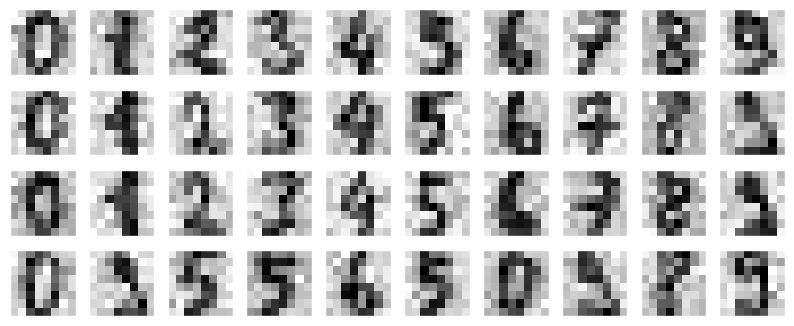

In [49]:
rng = np.random.RandomState(50)

#在指定的数据集中，随机抽取服从正态分布的数据
#两个参数，分别是指定的数据集，和抽取出来的正太分布的方差
#方差越大越凌乱
noisy = rng.normal(digits.data,2)
plot_digits(noisy)

In [50]:
pca = PCA(0.7,svd_solver='full').fit(noisy)

x_dr = pca.transform(noisy)
x_dr.shape

(1797, 13)

(1797, 64)

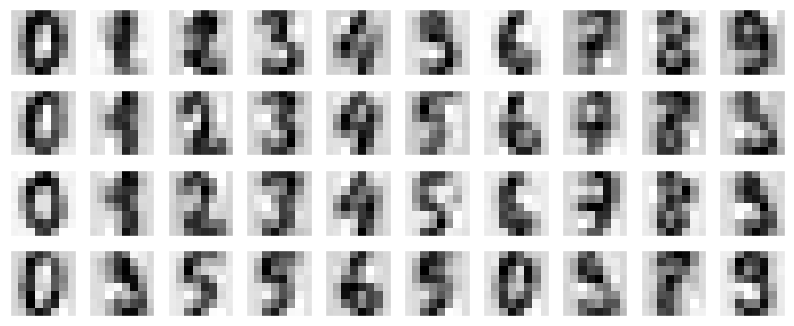

In [51]:
without_noise = pca.inverse_transform(x_dr)
without_noise.shape
plot_digits(without_noise)